## Practical Work 1

For this practical work, the student will have to develop a Python program that is able to implement the gradient descent in order to achieve the linear regression of a set of datapoints.

#### Import numpy, matplotlib.pyplot and make it inline

In [149]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#### Read RegData csv file into numpy array  (check your data)
##### Data source
https://college.cengage.com/mathematics/brase/understandable_statistics/7e/students/datasets/slr/frames/frame.html


In [150]:
data=np.array([[2.900000095,4],
[6.699999809,7.400000095],
[4.900000095,5],
[7.900000095,7.199999809],
[9.800000191,7.900000095],
[6.900000095,6.099999905],
[6.099999905,6],
[6.199999809,5.800000191],
[6,5.199999809],
[5.099999905,4.199999809],
[4.699999809,4],
[4.400000095,4.400000095],
[5.800000191,5.199999809]])

data=pd.DataFrame(data,columns=['X','Y'])

#### Explore your data

In [151]:
print(data.head())
print(f"{'-'*30}")
print(data.shape)
print(f"{'-'*30}")
print(data.describe())
print(f"{'-'*30}")
print(data.info())

     X    Y
0  2.9  4.0
1  6.7  7.4
2  4.9  5.0
3  7.9  7.2
4  9.8  7.9
------------------------------
(13, 2)
------------------------------
               X          Y
count  13.000000  13.000000
mean    5.953846   5.569231
std     1.714942   1.314271
min     2.900000   4.000000
25%     4.900000   4.400000
50%     6.000000   5.200000
75%     6.700000   6.100000
max     9.800000   7.900000
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       13 non-null     float64
 1   Y       13 non-null     float64
dtypes: float64(2)
memory usage: 340.0 bytes
None


#### Define variables X and y. Assign first column data to X and second column to y
<b>Note:</b> X is the independent variable (input to LR model) and y is the dependent variable (output)

In [152]:
x=data['X'].values
y=data['Y'].values

print(x)
print(y)

[2.9000001  6.69999981 4.9000001  7.9000001  9.80000019 6.9000001
 6.0999999  6.19999981 6.         5.0999999  4.69999981 4.4000001
 5.80000019]
[4.         7.4000001  5.         7.19999981 7.9000001  6.0999999
 6.         5.80000019 5.19999981 4.19999981 4.         4.4000001
 5.19999981]


#### Explore your data

#### Plot the original data (scatter plot of X,y)

Text(0.5, 1.0, 'Scatter Plot of X and Y')

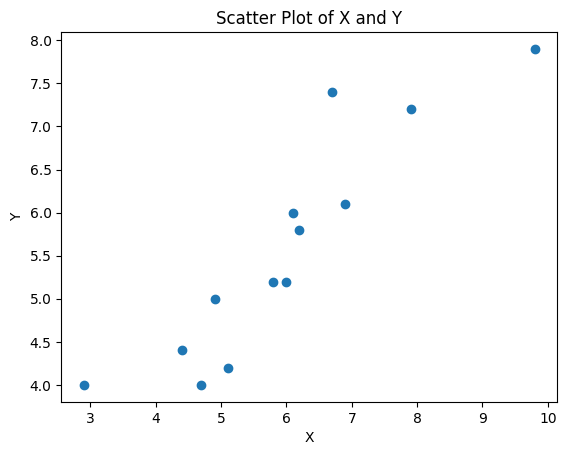

In [153]:
plt.scatter(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatter Plot of X and Y")

## LR Full Implementation

### Step1: Initialize parameters (theta_0 & theta_1) with random value or simply zero. Also choose the Learning rate. 

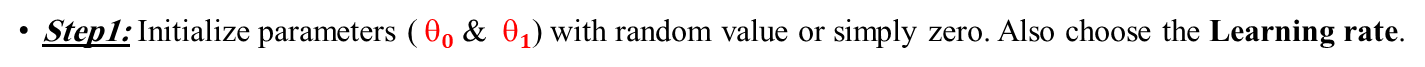

In [154]:
theta_0_old=0.5
theta_1_old=0.5
learning_rate=0.01

### Step2: Use (theta_0 & theta_1) to predict the output h(x)= theta_0 + theta_1 * x.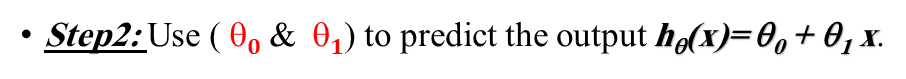
#### Note: you will need to iterate through all data points

In [155]:
#predict all data points
h=theta_0_old + theta_1_old * x
print(h)


[1.95000005 3.8499999  2.95000005 4.45000005 5.4000001  3.95000005
 3.54999995 3.5999999  3.5        3.04999995 2.8499999  2.70000005
 3.4000001 ]


### Step3: Calculate Cost function 𝑱(theta_0,theta_1 ).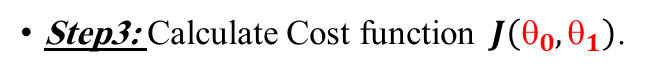
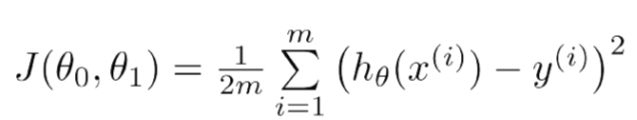

In [156]:
cost=np.sum((h - y) ** 2) / len(y)
print(cost)

4.765384530746181


### Step4: Calculate the gradient.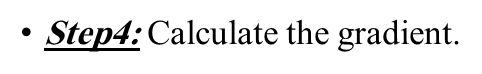
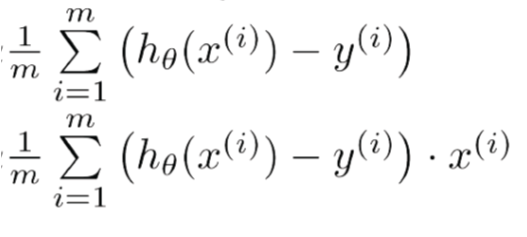

In [157]:
gradient_0 = (2/len(y)) * np.sum(h - y)
gradient_1 = (2/len(y)) * np.sum((h - y) * x)
print(gradient_0)
print(gradient_1)

-4.184615318461539
-25.970768830123042


### Step5: Update the parameters (simultaneously).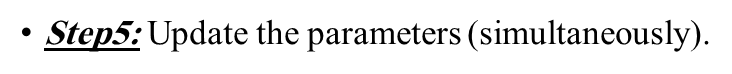
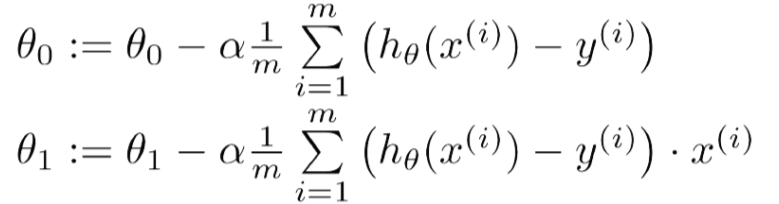

In [158]:
theta_0_new = theta_0_old - learning_rate * gradient_0
theta_1_new = theta_1_old - learning_rate * gradient_1
print(theta_0_new)
print(theta_1_new)

0.5418461531846154
0.7597076883012304


### Step6: Repeat from 2 to 5 until converge to the minimum or achieve maximum iterations.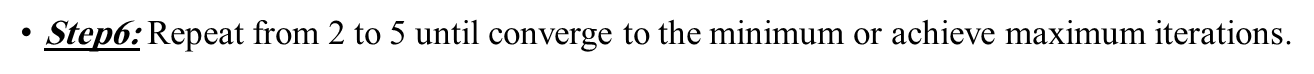

In [159]:
history=[]
for i in range(1000):
    h=theta_0_old + theta_1_old * x
    cost=np.sum((h - y) ** 2) / len(y)
    history.append(cost)
    gradient_0 = (2/len(y)) * np.sum(h - y)
    gradient_1 = (2/len(y)) * np.sum((h - y) * x)
    theta_0_new = theta_0_old - learning_rate * gradient_0
    theta_1_new = theta_1_old - learning_rate * gradient_1
    theta_0_old=theta_0_new
    theta_1_old=theta_1_new
    print(f"Iteration {i+1}: Cost={cost}, theta_0={theta_0_new}, theta_1={theta_1_new}")

print(f"Final parameters: theta_0={theta_0_new}, theta_1={theta_1_new}")


Iteration 1: Cost=4.765384530746181, theta_0=0.5418461531846154, theta_1=0.7597076883012304
Iteration 2: Cost=0.5506536807635255, theta_0=0.5519301908456496, theta_1=0.8162075748152992
Iteration 3: Cost=0.3499728346521831, theta_0=0.5550847151050018, theta_1=0.8283824946528779
Iteration 4: Cost=0.3402790061011831, theta_0=0.5567263968844391, theta_1=0.8308891353596299
Iteration 5: Cost=0.33967265403489333, theta_0=0.5580367619653058, theta_1=0.8312870672003413
Iteration 6: Cost=0.33949908266506806, theta_0=0.5592735352453114, theta_1=0.8312252387286118
Iteration 7: Cost=0.33934650451583415, theta_0=0.5604929354038979, theta_1=0.8310633303946424
Iteration 8: Cost=0.3391953258175487, theta_0=0.5617072271055656, theta_1=0.8308797980462455
Iteration 9: Cost=0.3390446131958643, theta_0=0.5629190874405587, theta_1=0.8306917547613473
Iteration 10: Cost=0.3388943211323578, theta_0=0.5641291021846502, theta_1=0.8305029330839601
Iteration 11: Cost=0.3387444463554528, theta_0=0.5653374009382406, 

Text(0.5, 1.0, 'Cost Function over Iterations')

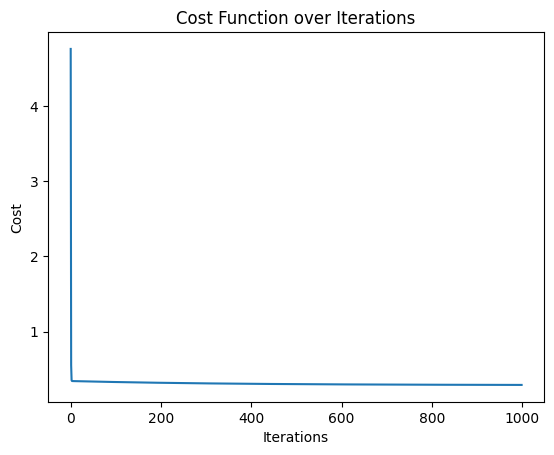

In [160]:
plt.plot(history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function over Iterations")

#### Predict y values using the LR equation
##### h(x)= theta_0 + theta_1 * x

In [161]:
y_pred=theta_0_new + theta_1_new * x

print(y_pred)

[3.32809272 6.09782382 4.78584604 6.97247602 8.35734174 6.24359936
 5.66049789 5.73338549 5.58761029 4.93162123 4.6400705  4.42140771
 5.4418351 ]


#### Plot  LR equation output (fitted line) with the original data (scatter plot of X,y)

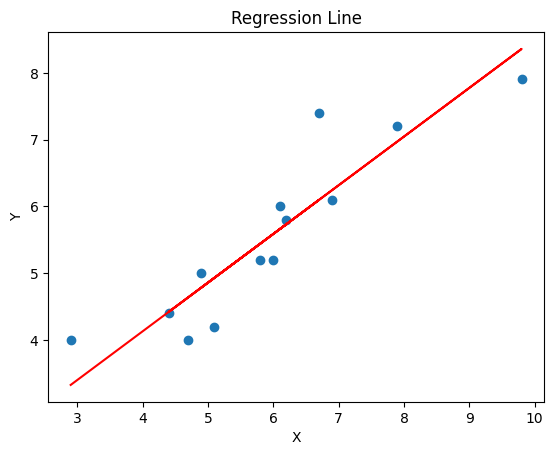

In [162]:
plt.scatter(x,y)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Regression Line")

plt.plot(x,y_pred, color='red')

plt.show()

#### Use R2 score to evaluate LR equation output
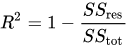
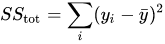
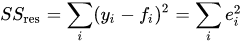
https://en.wikipedia.org/wiki/Coefficient_of_determination

In [163]:
from sklearn.metrics import r2_score 
r2 = r2_score(y, y_pred)
print(f"R-squared: {r2}")

R-squared: 0.8191608946429596


## GD vectorize Implementation
### Implement GD without iterate through data points i.e. use vector operations

In [164]:
ones=np.ones(shape=x.shape)
X_b=np.c_[ones, x]

thetas=np.array([theta_0_new, theta_1_new])


#### Plot the output and calculate R2 score
##### Make sure that you obtained the same results

In [165]:
y_pred_sk=X_b.dot(thetas)
print(y_pred_sk)

[3.32809272 6.09782382 4.78584604 6.97247602 8.35734174 6.24359936
 5.66049789 5.73338549 5.58761029 4.93162123 4.6400705  4.42140771
 5.4418351 ]


In [166]:
vectorized_r2 = r2_score(y, y_pred_sk)
print(f"R-squared vectorized: {vectorized_r2}")

R-squared vectorized: 0.8191608946429596


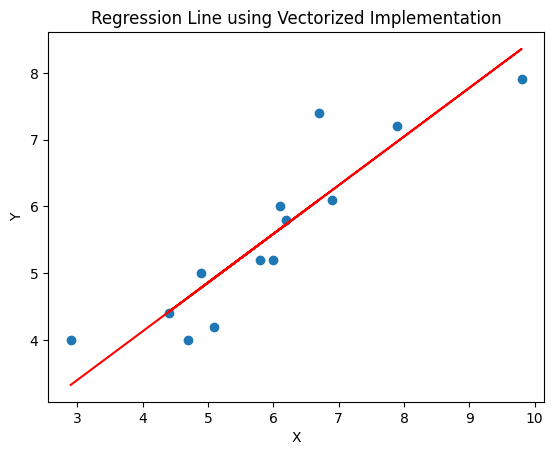

In [168]:
plt.scatter(x,y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Regression Line using Vectorized Implementation")
plt.plot(x, y_pred_sk, color='red')
plt.show()

## Plot loss function
### Repeat your last vectorized implementaion version and save loss for each iteration (epoch)

In [169]:
loss=[]
for i in range(1000):
    h=X_b.dot(thetas)
    cost=np.sum((h - y) ** 2) / len(y)
    loss.append(cost)
    gradients=(2/len(y)) * X_b.T.dot(h - y)
    thetas=thetas - learning_rate * gradients
    print(f"Iteration {i+1}: Cost={cost}, thetas={thetas}")
print(f"Final thetas from vectorized implementation: {thetas}")


Iteration 1: Cost=0.28833672819261136, thetas=[1.21465555 0.72882896]
Iteration 2: Cost=0.288327191447569, thetas=[1.21496034 0.72878132]
Iteration 3: Cost=0.28831768117467227, thetas=[1.21526471 0.72873375]
Iteration 4: Cost=0.28830819730044, thetas=[1.21556866 0.72868624]
Iteration 5: Cost=0.28829873975159487, thetas=[1.21587219 0.7286388 ]
Iteration 6: Cost=0.2882893084550624, thetas=[1.21617529 0.72859143]
Iteration 7: Cost=0.2882799033379714, thetas=[1.21647797 0.72854412]
Iteration 8: Cost=0.28827052432765277, thetas=[1.21678024 0.72849688]
Iteration 9: Cost=0.28826117135163903, thetas=[1.21708208 0.7284497 ]
Iteration 10: Cost=0.28825184433766454, thetas=[1.21738351 0.72840259]
Iteration 11: Cost=0.2882425432136631, thetas=[1.21768451 0.72835554]
Iteration 12: Cost=0.2882332679077696, thetas=[1.2179851  0.72830856]
Iteration 13: Cost=0.2882240183483181, thetas=[1.21828527 0.72826165]
Iteration 14: Cost=0.2882147944638413, thetas=[1.21858502 0.7282148 ]
Iteration 15: Cost=0.28820

### Plot loss vs. iterations

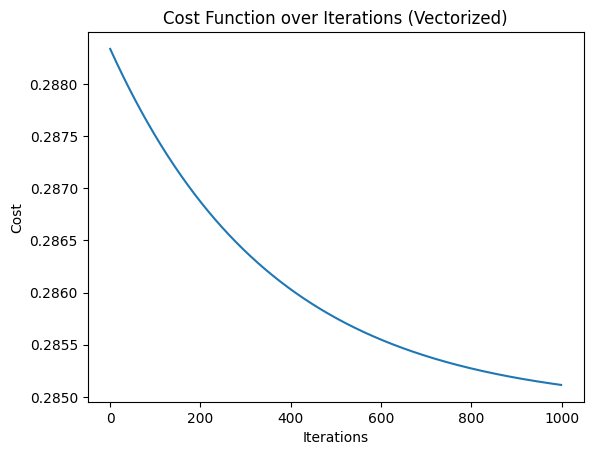

In [170]:
plt.plot(loss)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function over Iterations (Vectorized)")
plt.show()

## Multivariate LR

#### Read MultipleLR csv file into numpy array  (check your data)
##### Data source
https://college.cengage.com/mathematics/brase/understandable_statistics/7e/students/datasets/slr/frames/frame.html


In [171]:
data2=np.array([[73,80,75,152],
[93,88,93,185],
[89,91,90,180],
[96,98,100,196],
[73,66,70,142],
[53,46,55,101],
[69,74,77,149],
[47,56,60,115],
[87,79,90,175],
[79,70,88,164],
[69,70,73,141],
[70,65,74,141],
[93,95,91,184],
[79,80,73,152],
[70,73,78,148],
[93,89,96,192],
[78,75,68,147],
[81,90,93,183],
[88,92,86,177],
[78,83,77,159],
[82,86,90,177],
[86,82,89,175],
[78,83,85,175],
[76,83,71,149],
[96,93,95,192]])

data2=pd.DataFrame(data2,columns=['Exam1','Exam2','Exam3','Score'])
print(data2.head())

   Exam1  Exam2  Exam3  Score
0     73     80     75    152
1     93     88     93    185
2     89     91     90    180
3     96     98    100    196
4     73     66     70    142


In [172]:
print(data2.head())
print(f"{'-'*30}")
print(data2.shape)
print(f"{'-'*30}")
print(data2.describe())
print(f"{'-'*30}")
print(data2.info())

   Exam1  Exam2  Exam3  Score
0     73     80     75    152
1     93     88     93    185
2     89     91     90    180
3     96     98    100    196
4     73     66     70    142
------------------------------
(25, 4)
------------------------------
           Exam1      Exam2       Exam3       Score
count  25.000000  25.000000   25.000000   25.000000
mean   79.040000  79.480000   81.480000  162.040000
std    12.279658  12.503733   11.765486   24.044195
min    47.000000  46.000000   55.000000  101.000000
25%    73.000000  73.000000   73.000000  148.000000
50%    79.000000  82.000000   85.000000  164.000000
75%    88.000000  89.000000   90.000000  180.000000
max    96.000000  98.000000  100.000000  196.000000
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Exam1   25 non-null     int64
 1   Exam2   25 non-null     int64
 2   Exam

In [ ]:
X=data2[['Exam1','Exam2','Exam3']].values
y=data2['Score'].values

In [174]:
X_b2=np.c_[np.ones((X.shape[0],1)), X]
theatas=np.zeros(X_b2.shape[1])
learning_rate=0.00001

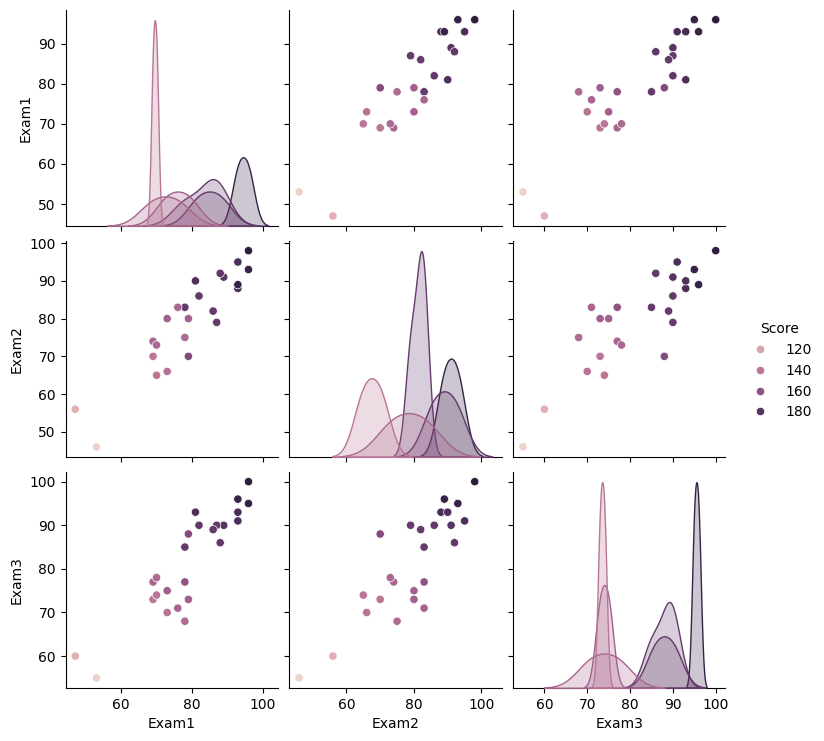

In [175]:
sns.pairplot(data2,hue='Score')
plt.show()

### Repeat your implementation but for more than one variable

In [177]:
cost_history=[]
for i in range(10000):
    h=X_b2.dot(theatas)
    cost=np.sum((h-y) ** 2) / len(y)
    cost_history.append(cost)
    gradients=(2/len(y))*X_b2.T.dot(h-y)
    theatas=theatas - learning_rate * gradients
    print(f"Iteration {i+1}: Cost={cost}, thetas={theatas}")
print(f"Final thetas from vectorized implementation: {theatas}")

Iteration 1: Cost=7.37605094722746, thetas=[0.00677024 0.54139933 0.55769175 0.92008139]
Iteration 2: Cost=7.37514750267735, thetas=[0.00676919 0.54135158 0.55766121 0.92015765]
Iteration 3: Cost=7.374244746263838, thetas=[0.00676814 0.54130384 0.55763069 0.92023388]
Iteration 4: Cost=7.373342677432527, thetas=[0.00676708 0.54125612 0.55760019 0.92031008]
Iteration 5: Cost=7.372441295629523, thetas=[0.00676603 0.54120841 0.5575697  0.92038625]
Iteration 6: Cost=7.371540600301321, thetas=[0.00676498 0.54116071 0.55753924 0.92046239]
Iteration 7: Cost=7.370640590895094, thetas=[0.00676393 0.54111302 0.55750879 0.9205385 ]
Iteration 8: Cost=7.36974126685819, thetas=[0.00676288 0.54106535 0.55747836 0.92061458]
Iteration 9: Cost=7.3688426276385846, thetas=[0.00676182 0.54101769 0.55744795 0.92069063]
Iteration 10: Cost=7.367944672684713, thetas=[0.00676077 0.54097004 0.55741756 0.92076665]
Iteration 11: Cost=7.367047401445394, thetas=[0.00675972 0.5409224  0.55738718 0.92084265]
Iteration 

#### Predict y values using the LR equation
##### h(x)= theta_0 + theta_1 * x1 + theta_2 * x2 + theta_3 * x3

In [180]:
y_pred_sk=X_b2.dot(theatas)
print(y_pred_sk)

[152.90425969 184.65337841 181.38555228 198.83912608 139.97255574
 105.29206896 150.51524634 113.90334972 174.35566459 164.43556033
 143.94296215 142.81251209 186.08358503 152.89046329 151.48095126
 188.53451406 144.30439669 181.25291949 177.06275046 158.56799736
 176.17037897 174.43803716 167.52025576 151.11238083 190.62377085]


### Plot loss vs. iterations

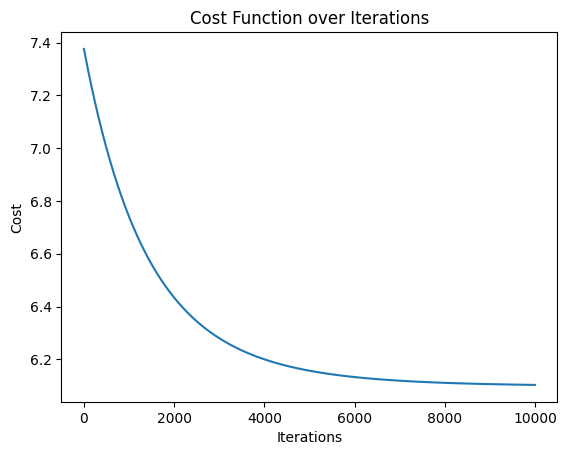

In [181]:
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function over Iterations")
plt.show()

#### Use R2 score to evaluate LR equation output

In [182]:
print(f"R2 score: {r2_score(y, y_pred_sk)}")

R2 score: 0.9890034180454312


# Bonus
## LR Using sklearn

### Single Variable

#### Build a LR model usin linearmodel.LinearRegression() from sklearn library

In [183]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [185]:
x_lr=data2["Exam1"].values.reshape(-1,1)
y_lr=data2["Score"].values.reshape(-1,1)

#### Train the model (fit the model to the training data)

In [186]:
model.fit(x_lr, y_lr)

LinearRegression()

#### Predict y values using the trained model

In [189]:
y_pred_sk1=model.predict(x_lr)

#### Plot model output (fitted line) with the original data (scatter plot of X,y)

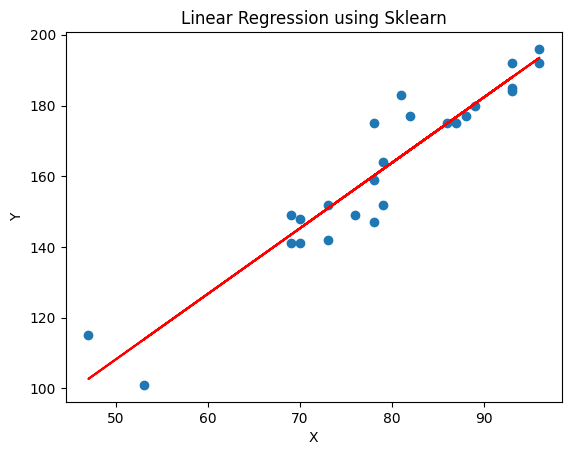

In [191]:
plt.scatter(data2["Exam1"], data2["Score"])
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression using Sklearn')
plt.plot(x_lr, y_pred_sk1, color='red')
plt.show()

#### Use R2 score to evaluate model output

In [192]:
print(f"r2 score: {r2_score(y_lr, y_pred_sk1)}")

r2 score: 0.8950500188020498


### Repeat for Mulivariate

In [193]:
model.fit(X, y)
y_pred_model=model.predict(X)

In [199]:
print(f"R2 score: {r2_score(y, y_pred_model)}")

R2 score: 0.9896615789448399


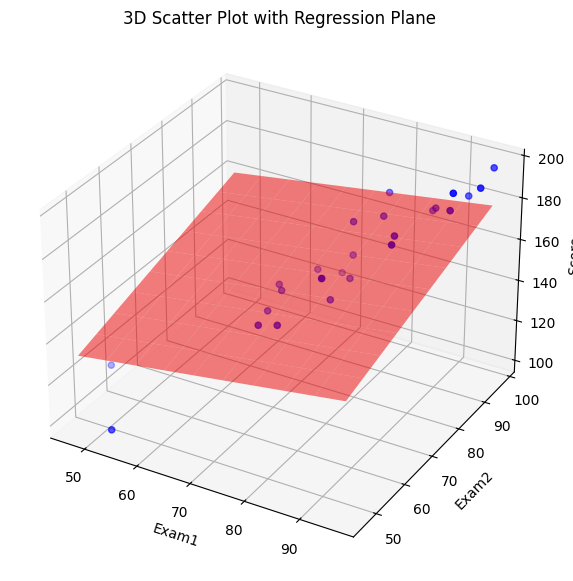

In [ ]:
fig=plt.figure(figsize=(10,7))
ax=fig.add_subplot(111, projection='3d')
ax.scatter(data2['Exam1'], data2['Exam2'], data2['Score'], c='b', marker='o')
ax.set_xlabel('Exam1')
ax.set_ylabel('Exam2')
ax.set_zlabel('Score')
ax.set_title('3D Scatter Plot with Regression Plane')

exam1_range = np.linspace(data2['Exam1'].min(), data2['Exam1'].max(), 10)
exam2_range = np.linspace(data2['Exam2'].min(), data2['Exam2'].max(), 10)
exam1_mesh, exam2_mesh = np.meshgrid(exam1_range, exam2_range)

score_mesh = model.predict(np.c_[exam1_mesh.ravel(), exam2_mesh.ravel(), np.full(exam1_mesh.ravel().shape, data2['Exam3'].mean())])
score_mesh = score_mesh.reshape(exam1_mesh.shape)

ax.plot_surface(exam1_mesh, exam2_mesh, score_mesh, color='r', alpha=0.5)
plt.show()